#Projet-Final — Pipeline de Régression Linéaire

### Analyse et Algèbre Linéaire avec Numpy I
 M. Cheikhou Akhmed KANE
 Enseignant-chercheur | Université Rose Dieng France-Sénégal

 Etudiante : Khadidiatou Diasse



Contexte
Nous venons d'intégrer le pôle Data d'un établissement scolaire qui souhaite moderniser son suivi pédagogique. Jusqu'ici, les enseignants repèrent les élèves en difficulté après la publication des notes finales — trop tard pour intervenir efficacement.

La direction pédagogique nous confie une mission claire :

Construire un modèle prédictif capable d'estimer la note finale d'un élève en cours d'année, à partir de son comportement scolaire (assiduité, temps de travail) et de ses résultats aux trimestres précédents. L'objectif est de détecter tôt les élèves à risque, pour permettre un accompagnement ciblé avant l'examen final.





## Sprint 0 — Mise en place
### "Avant de coder quoi que ce soit, il faut charger les données et comprendre leur structure."

# Chargement du dataset

Nous disposons d'un historique de 395 élèves, décrits par les variables suivantes :

| Variable | Description | Unité |
|:---|:---|:---:|
| `Temps_Etude_Hebdo` |Temps d'étude personnel par semaine |heures |
| `Nombre_Echecs_Passes` |Nombre d'échecs scolaires antérieurs | — |
| `Nombre_Absences` | Nombre d'absences sur l'année | — |
| `Note_Premier_Trimestre` | Note obtenue au 1er trimestre | /20 |
| `Note_Deuxieme_Trimestre` | Note obtenue au 2e trimestre | /20 |
| `Note_Finale` | Note finale obtenue —  **variable cible** $\color{orange}{y}$ | /20 |

Notre mission, en tant que Data Scientists : construire le pipeline complet — de l'analyse exploratoire à l'implémentation mathématique de la régression linéaire (Équation Normale, en NumPy pur) — afin de fournir à l'équipe pédagogique un outil de prédiction fiable, interprétable, et reproductible

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Chargement du dataset
URL = "https://raw.githubusercontent.com/khadidiatoudiasse46-png/regression-lineaire-notes-etudiants/refs/heads/main/data/student_data_regression_fr.csv"
data = np.genfromtxt(URL, delimiter=',', skip_header=1)

print(f"Forme du dataset : {data.shape}")
print(f"\nAperçu (5 premières lignes) :")
print()
print(f"{'Temps_Etude_Hebdo':>25} {'Nombre_Echecs_Passes':>25}  "
      f"{'Nombre_Absences':>20} {'Note_Premier_Trimestre':>25}"
      f"{'Note_Deuxieme_Trimestre':>25} {'Note_Finale':>12}"
      )

print("-" * 150)
for row in data[:5]:
    print(f"{row[0]:>25.0f} {row[1]:>25.0f} {row[2]:>20.1f} "
          f"{row[3]:>25.0f} {row[4]:>25.0f} {row[5]:>12.0f}")

Forme du dataset : (395, 6)

Aperçu (5 premières lignes) :

        Temps_Etude_Hebdo      Nombre_Echecs_Passes       Nombre_Absences    Note_Premier_Trimestre  Note_Deuxieme_Trimestre  Note_Finale
------------------------------------------------------------------------------------------------------------------------------------------------------
                        2                         0                  6.0                         5                         6            6
                        2                         0                  4.0                         5                         5            6
                        2                         3                 10.0                         7                         8           10
                        3                         0                  2.0                        15                        14           15
                        2                         0                  4.0                         6 

## Nettoyage du dataset

In [2]:
import pandas as pd

#nettoyages du dataset en supprimant les doublons
print(f"Avant nettoyage dataset :{data.shape}")

# 1. On convertit le tableau numpy en DataFrame Pandas
data_df = pd.DataFrame(data)
data_df = data_df.drop_duplicates()

if data.shape == data_df.shape:
    print(f"Votre dataset est propre ne contient pas de doublons :{data_df.shape}")
else:
    print(f"Apres nettoyage dataset :{data_df.shape}")

#verifier s'il y'a des donnees manquantes
print(f"Les colonnes avec le nombres de valeurs manquantes {data_df.isnull().sum()}")

# supprimer les notes finale(y) egale à 0
if ((data_df[5] == 0).sum()) == 0:
    print(f"Pas de note finale égale à 0")
else:
    print(f"le nombre de note finale égale à 0 est :{(data_df[5] == 0).sum()} ")
    print(f"Alors on doit supprimer ses lignes là :")
    data_df = data_df.drop(data_df[data_df[5] == 0].index)
    print(f"apres la supréssion le dataset est de dimension: {data_df.shape}")

# verifier si les trois derniers colonnes on des notes entre 0 et 20
data_df = data_df[
    ((data_df.iloc[:, -3:] > 0) & (data_df.iloc[:, -3:] <= 20)).all(axis=1)]
print(data_df.shape)






Avant nettoyage dataset :(395, 6)
Apres nettoyage dataset :(380, 6)
Les colonnes avec le nombres de valeurs manquantes 0    0
1    0
2    0
3    0
4    0
5    0
dtype: int64
le nombre de note finale égale à 0 est :35 
Alors on doit supprimer ses lignes là :
apres la supréssion le dataset est de dimension: (345, 6)
(345, 6)


# Sprint 1 — Exploration des données

## Sprint 1 — Exploration des données

**Le pitch du CTO** : "On ne construit jamais un modèle à l'aveugle. Avant de toucher à la moindre formule mathématique, il faut comprendre la forme de nos données, repérer les relations entre variables, et vérifier que notre hypothèse de linéarité tient la route."

Dans ce sprint, nous allons :
- Examiner la distribution de chaque variable
- Visualiser la relation entre chaque variable explicative et la note finale
- Quantifier ces relations à travers une matrice de corrélation

Cette étape est essentielle : elle conditionne directement notre choix de modèle. Si aucune variable n'est linéairement liée à `Note_Finale`, la régression linéaire ne sera pas pertinente.

In [3]:

# Renommer les colonnes avec les vrais noms de variables
data_df.columns = ['Temps_Etude_Hebdo', 'Nombre_Echecs_Passes', 'Nombre_Absences',
                    'Note_Premier_Trimestre', 'Note_Deuxieme_Trimestre', 'Note_Finale']
data_df = data_df.reset_index(drop=True)

# --- Statistiques descriptives ---
data_df.describe()



,Temps_Etude_Hebdo,Nombre_Echecs_Passes,Nombre_Absences,Note_Premier_Trimestre,Note_Deuxieme_Trimestre,Note_Finale
count,345.000000,345.000000,345.000000,345.000000,345.000000,345.000000
mean,2.043478,0.281159,6.437681,11.237681,11.318841,11.478261
std,0.846243,0.681413,8.288215,3.255813,3.163623,3.247578
min,1.000000,0.000000,0.000000,3.000000,5.000000,4.000000
25%,1.000000,0.000000,2.000000,9.000000,9.000000,9.000000
50%,2.000000,0.000000,4.000000,11.000000,11.000000,11.000000
75%,2.000000,0.000000,8.000000,14.000000,13.000000,14.000000
max,4.000000,3.000000,75.000000,19.000000,19.000000,20.000000


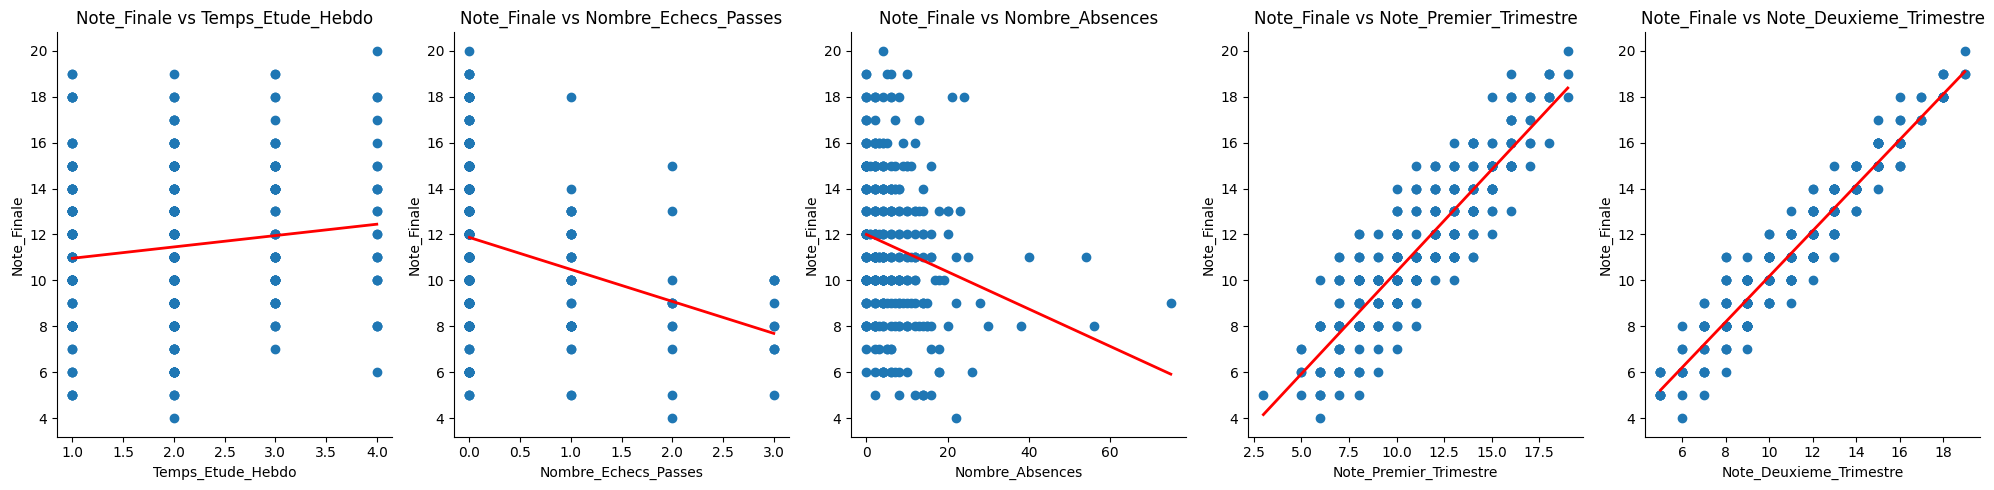

In [4]:
# transformation du dataframe en np.array
data_array = np.array(data_df)

# Création des graphiques
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

# Temps_Etude_Hebdo vs Note_Finale
axes[0].scatter(data_array[:, 0], data_array[:,-1])
a, b = np.polyfit(data_array[:, 0], data_array[:,-1], 1)
x_droite = np.linspace(data_array[:, 0].min(), data_array[:, 0].max(), 100)
axes[0].plot(x_droite, a * x_droite + b, color='red', linewidth=2)
axes[0].set_title("Note_Finale vs Temps_Etude_Hebdo")
axes[0].set_xlabel("Temps_Etude_Hebdo")
axes[0].set_ylabel("Note_Finale")

# Nombre_Echecs_Passes vs Note_Finale
axes[1].scatter(data_array[:, 1], data_array[:,-1])
a, b = np.polyfit(data_array[:, 1], data_array[:,-1], 1)
x_droite = np.linspace(data_array[:, 1].min(), data_array[:, 1].max(), 100)
axes[1].plot(x_droite, a * x_droite + b, color='red', linewidth=2)
axes[1].set_title("Note_Finale vs Nombre_Echecs_Passes")
axes[1].set_xlabel("Nombre_Echecs_Passes")
axes[1].set_ylabel("Note_Finale")

# Nombre_Absences vs Note_Finale
axes[2].scatter(data_array[:, 2], data_array[:,-1])
a, b = np.polyfit(data_array[:, 2], data_array[:,-1], 1)
x_droite = np.linspace(data_array[:, 2].min(), data_array[:, 2].max(), 100)
axes[2].plot(x_droite, a * x_droite + b, color='red', linewidth=2)
axes[2].set_title("Note_Finale vs Nombre_Absences")
axes[2].set_xlabel("Nombre_Absences")
axes[2].set_ylabel("Note_Finale")

# Note_Premier_Trimestre vs Note_Finale
axes[3].scatter(data_array[:, 3], data_array[:,-1])
a, b = np.polyfit(data_array[:, 3], data_array[:,-1], 1)
x_droite = np.linspace(data_array[:, 3].min(), data_array[:, 3].max(), 100)
axes[3].plot(x_droite, a * x_droite + b, color='red', linewidth=2)
axes[3].set_title("Note_Finale vs Note_Premier_Trimestre")
axes[3].set_xlabel("Note_Premier_Trimestre")
axes[3].set_ylabel("Note_Finale")

# Note_Deuxieme_Trimestre vs Note_Finale
axes[4].scatter(data_array[:, 4], data_array[:,-1])
a, b = np.polyfit(data_array[:, 4], data_array[:,-1], 1)
x_droite = np.linspace(data_array[:, 4].min(), data_array[:, 4].max(), 100)
axes[4].plot(x_droite, a * x_droite + b, color='red', linewidth=2)
axes[4].set_title("Note_Finale vs Note_Deuxieme_Trimestre")
axes[4].set_xlabel("Note_Deuxieme_Trimestre")
axes[4].set_ylabel("Note_Finale")

# Ajustement automatique
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
plt.tight_layout()

# Affichage
plt.show()



Cette analyse confirme que notre hypothèse de départ — une relation linéaire entre les variables explicatives et la note finale — est globalement valide, principalement portée par les notes des trimestres précédents. Nous nous attendons donc à ce que le modèle de régression linéaire accorde un poids (coefficient θ) élevé à `Note_Premier_Trimestre` et `Note_Deuxieme_Trimestre`, et un poids plus faible à `Temps_Etude_Hebdo` et `Nombre_Absences`. Cette intuition sera vérifiée lors de l'interprétation des coefficients θ* dans la suite du projet.

## Sprint 2 — Construction du pipeline de régression

**Le pitch du CTO** : "L'exploration nous a confirmé que nos variables ont une relation linéaire plausible avec la note finale. Il est temps de construire le cœur de notre produit : le pipeline mathématique complet. Chaque ligne de code doit être directement reliée à la formule mathématique qu'elle implémente — c'est ce qui rendra notre solution fiable, auditable, et réutilisable sur n'importe quel futur client."

Dans ce sprint, nous allons :
- Construire la matrice de design X (avec la colonne de biais)
- Vérifier que la matrice XᵀX est inversible
- Résoudre l'Équation Normale pour obtenir θ*
- Calculer les prédictions du modèle
- Évaluer la qualité de ces prédictions

### 1. Recuperons la matrice X et y et Construire la matrice de design X (avec la colonne de biais)

In [5]:

#Construire la matrice X
X = data_array[:,:5]
print(f"voici la matice X :\n{X}")
print()

#Construire la matrice y
y = data_array[:,-1]
print(f"voici la matice y:\n{y}")


voici la matice X :
[[ 2.  0.  6.  5.  6.]
 [ 2.  0.  4.  5.  5.]
 [ 2.  3. 10.  7.  8.]
 ...
 [ 1.  3.  3. 10.  8.]
 [ 1.  0.  0. 11. 12.]
 [ 1.  0.  5.  8.  9.]]

voici la matice y:
[ 6.  6. 10. 15. 10. 15. 11.  6. 19. 15.  9. 12. 14. 11. 16. 14. 14. 10.
  5. 10. 15. 15. 16. 12.  8.  8. 11. 15. 11. 11. 12. 17. 16. 12. 15.  6.
 18. 15. 11. 13. 11. 12. 18. 11.  9.  6. 11. 20. 14.  7. 13. 13. 10. 11.
 13. 10. 15.  9. 16. 11. 11.  9.  9. 10. 15. 12.  6.  8. 16. 15. 10.  5.
 14. 11. 10. 10. 11. 10.  5. 12. 11.  6. 15. 10.  8.  6. 14. 10.  7.  8.
 18.  6. 10. 14. 10. 15. 10. 14.  8.  5. 17. 14.  6. 18. 11.  8. 18. 13.
 16. 19. 10. 13. 19.  9. 14. 13.  8. 13. 15. 13. 13.  8. 12. 11.  9. 18.
 12. 11. 12. 15.  9. 11. 13. 11. 11. 10. 14. 10. 12.  8. 13. 10. 15. 12.
  7. 10.  7. 12. 10. 16. 14. 16. 10.  9.  9. 11.  6.  9. 11.  8. 12. 17.
  8. 12. 11. 11. 15.  9. 10. 13.  9.  8. 10. 14. 16. 10. 18. 10. 16. 10.
 10.  6. 11.  9.  7. 10.  7.  8. 13. 14.  8. 10. 15.  4.  8.  8. 10.  6.
 17. 13. 14. 

Definissons la fonction add biais pour ajouter 1 à chaque ligne de la matrice X

In [6]:
def add_bias(X):

    if X.ndim != 2:
        raise ValueError(f"X doit être un tableau à 2 dimensions (n, p) — obtenu {X.ndim}D")


    # construisons la la matrice X_b la matice de disign
    n = X.shape[0]
    X_b = np.hstack([np.ones((n, 1)), X])
    return X_b



### 2. Vérifier que la matrice XᵀX est inversible

on va ecrire une fonction qui definie si la matrice est inversible avant d'appliquer l'equation normale

In [7]:

def check_array(X_b):
    """
    Vérifie si la matrice X_b^T X_b est inversible et numériquement stable.
    """
    # Messages d'avertissement
    WARNING_RANK = "Rang insuffisant : rang(X_b) = {rang} < {p1} — colonnes linéairement dépendantes, Équation Normale inapplicable."
    WARNING_DET  = "Déterminant nul : det(X_b^T X_b) ≈ 0 — matrice singulière, Équation Normale inapplicable."
    WARNING_COND = "Conditionnement élevé : κ = {cond:.2e} > 1e6 — solution numériquement instable, résultats à interpréter avec prudence."

    # 2. Calcul du rang, du déterminant et du conditionnement
    rang  = np.linalg.matrix_rank(X_b)
    deter = np.linalg.det(X_b.T @ X_b)
    condi = np.linalg.cond(X_b.T @ X_b)

    # 3. Construction de la liste des warnings selon les conditions violées
    p = X_b.shape[1]
    is_valid = True
    warning = []

    if rang < p:
        warning.append(WARNING_RANK.format(rang=rang, p1=p))
        is_valid = False

    if abs(deter) < 1e-10:
        warning.append(WARNING_DET)
        is_valid = False

    if condi > 1e6:
        warning.append(WARNING_COND.format(cond=condi))
        is_valid = False

    return {
        "rang"     : rang,
        "det"      : deter,
        "cond"     : condi,
        "is_valid" : is_valid,
        "warnings" : warning
    }

## 3. Résoudre l'Équation Normale pour obtenir θ*

L'Équation Normale donne la formule pour trouver les meilleurs θ* directement :
θ* = (XᵀX)⁻¹ Xᵀy

In [8]:
def fit(X, y, fit_intercept=True):
# Résolution de l'Équation Normale : θ* = (X_b^T X_b)^(-1) X_b^T y

    # 1. Vérifions que X et y ont le même nombre de lignes
    if X.shape[0] != y.shape[0]:
        raise ValueError(
          f"X et y doivent avoir le même nombre de lignes — "
          f"obtenu X:{X.shape[0]} et y:{y.shape[0]}"
        )

    # 2. Construisons X_b selon fit_intercept

    if fit_intercept:
        X_b = add_bias(X)
    else:
        X_b = X

    # 3. Appelons check_array
    #    Si is_valid=False : affichons les warnings et retournons
    #    {"theta": None, "diagnostic": diagnostic, "gradient": None}

    diagnostic = check_array(X_b)
    if diagnostic["is_valid"] == False:
      return{"theta": None, "diagnostic": diagnostic}
    else:
    # 4. Résolvons l'Équation Normale avec np.linalg.solve
        A = X_b.T @ X_b
        b = X_b.T @ y
        theta = np.linalg.solve(A, b)

        # 6. Retournons le dictionnaire
        resultat = {
            "theta":theta,
            "diagnostic": diagnostic
        }
        return resultat

## 4. Prédiction

Maintenant que nous disposons de θ*, le modèle est entraîné. Nous pouvons l'utiliser pour générer des prédictions de note finale à partir des variables explicatives, en appliquant directement la formule du modèle linéaire : ŷ = X_b @ θ*. Cette étape nous permettra, dans la partie suivante, de comparer ces prédictions aux vraies notes finales et d'évaluer objectivement la qualité de notre modèle.

In [9]:
def predict(X, theta, fit_intercept=True):

    # 1. Vérifiez la cohérence des dimensions selon fit_intercept
    if fit_intercept and X.shape[1] + 1 != theta.shape[0]:
        raise ValueError(
            f"Dimensions incompatibles : X a {X.shape[1]} features "
            f"mais theta a {theta.shape[0]} éléments (biais inclus attendu)"
        )
    if not fit_intercept and X.shape[1] != theta.shape[0]:
        raise ValueError(
            f"Dimensions incompatibles : X a {X.shape[1]} features "
            f"mais theta a {theta.shape[0]} éléments"
        )

    # 2. Construisez X_b selon fit_intercept
     #    Rappel : add_bias(X)
    if fit_intercept:
       X_b = add_bias(X)
    else:
        X_b = X

    # 3. Calculez et retournez les prédictions
    y_hat = X_b @ theta
    return y_hat

## 5. Évaluation

Une prédiction n'a de valeur que si l'on peut mesurer objectivement sa qualité. Nous évaluons à présent notre modèle à l'aide de deux métriques complémentaires : la MSE (Mean Squared Error), qui mesure la moyenne des erreurs au carré entre nos prédictions et les vraies notes finales, et la RMSE (Root Mean Squared Error), sa racine carrée, qui ramène cette erreur dans la même unité que la note finale (sur 20) — ce qui la rend directement interprétable. Ces deux indicateurs nous permettront de juger objectivement la précision de notre modèle entraîné avec l'Équation Normale.

In [10]:
def evaluate(y, y_hat):

    # calculons la mse / np.mean((y-y_hat)**2)
    mse = np.mean((y-y_hat)**2)

    #calculer la rmse /np.sqrt(mse)
    rmse = np.sqrt(mse)

    # 2. Retournons le dictionnaire
    return{'mse': mse, 'rmse': rmse}

## 6. Premières prédictions

Notre pipeline est maintenant complet : construction de la matrice de design, vérification de l'inversibilité, résolution de l'Équation Normale. Il est temps de l'utiliser concrètement. Nous ajustons ici notre modèle sur l'ensemble du dataset nettoyé, afin d'obtenir un premier jeu de coefficients θ* et d'évaluer la qualité globale de nos prédictions, avant de passer à une validation plus rigoureuse avec une séparation train/test.

1. Appelez `fit(X, y)` et affichez $\color{green}{\theta^*}$ et le diagnostic
2. Appelez `predict(X, theta_star)` pour obtenir $\color{violet}{\widehat{y}}$
3. Appelez `evaluate(y, y_hat)` et affichez MSE et RMSE
4. Interprétez chaque composante de $\color{green}{\theta^*}$ — que représente $\color{green}{\theta_1^*}$ dans le contexte scolaire ?
5. Tracez un scatterplot **notes réelles vs notes prédites** — ajoutez la droite $y = \hat{y}$ en pointillés rouges. Un modèle parfait alignerait tous les points sur cette droite.

théta: [ 0.24283673  0.02369449  0.0270906  -0.01159063  0.12524352  0.8699264 ]
{'mse': np.float64(0.6825174441388818), 'rmse': np.float64(0.8261461396985897)}


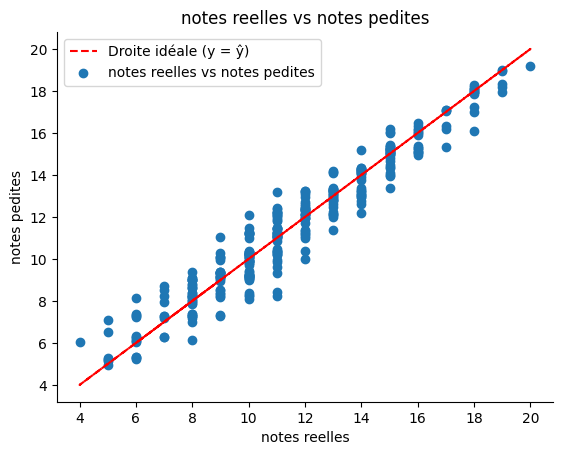

In [11]:

#Appelons fit(X, y) et affichons  θ∗  et le diagnostic
diagnostics = fit(X, y, fit_intercept=True)

#Appelons predict(X, theta_star) pour obtenir  yˆ
y_hat = predict(X, diagnostics['theta'])
print(f"théta: {diagnostics['theta']}")

# Appelons evaluate(y, y_hat) et affichons MSE et RMSE
print(evaluate(y, y_hat))

#Tracons un scatterplot notes reelles vs notes prédits — ajoutons la droite  y=y^  en pointillés rouges. Un modèle parfait alignerait tous les points sur cette droite.
plt.plot(y, y,
         color='red',
         linestyle='--',
         label='Droite idéale (y = ŷ)')

plt.scatter(y, y_hat,
            label='notes reelles vs notes pedites')
plt.xlabel("notes reelles")
plt.ylabel("notes pedites")
plt.title("notes reelles vs notes pedites")
plt.legend()

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.grid(False)

plt.show()




# Sprint 3 — Validation du modèle (train/test)

**Le pitch du CTO** : "Notre pipeline fonctionne — nous savons construire la matrice de design, vérifier l'inversibilité, résoudre l'Équation Normale, prédire et évaluer. Mais jusqu'ici, nous avons entraîné et évalué notre modèle sur les mêmes données. Cela ne prouve pas qu'il fonctionnera sur de nouveaux élèves. Avant de livrer ce modèle à l'équipe pédagogique, il faut le tester sur des données qu'il n'a jamais vues."

Dans ce sprint, nous allons séparer notre jeu de données en un ensemble d'entraînement (80%) et un ensemble de test (20%), réentraîner notre pipeline uniquement sur l'ensemble d'entraînement, puis comparer ses performances sur les deux ensembles afin de vérifier que notre modèle généralise correctement.

In [12]:
def train_test_split(X, y, test_size=0.2, random_state=42):
    """
    Divise X et y en ensembles d'entraînement et de test.

    Le dataset est d'abord mélangé aléatoirement avant la division —
    pour éviter que les données soient groupées """


    np.random.seed(random_state)

    n = X.shape[0]
    n_test  = int(n * test_size)
    n_train = n - n_test

    # Mélanger les indices aléatoirement
    indices = np.random.permutation(n)

    train_idx = indices[:n_train]
    test_idx  = indices[n_train:]

    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

In [13]:
# Vérification — train_test_split,

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train : {X_train.shape[0]} eleves")
print(f"Test  : {X_test.shape[0]} eleves")
print(f"Total : {X_train.shape[0] + X_test.shape[0]} eleves")

Train : 276 eleves
Test  : 69 eleves
Total : 345 eleves


MSE  train : 0.647   |   MSE  test : 0.838
RMSE train : 0.804   |   RMSE test : 0.915
--------------------------------------------------------------------------------

Le RMSE du jeu d'entraînement est de 0.804, contre 0.915 sur le jeu de test.
Ces valeurs restent proches : le modèle généralise bien.



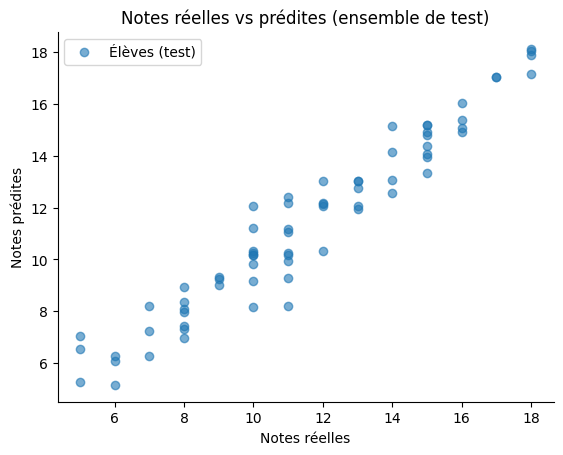

In [14]:

# 1. Diviser le dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Entraîner UNIQUEMENT sur le train
resultat_fit = fit(X_train, y_train, fit_intercept=True)
theta_star = resultat_fit["theta"]

# 3. Prédire sur train et test avec le même theta_star
y_hat_train = predict(X_train, theta_star)
y_hat_test = predict(X_test, theta_star)

# 4. Évaluer sur les deux ensembles
resultat_eval_train = evaluate(y_train, y_hat_train)
resultat_eval_test = evaluate(y_test, y_hat_test)

mse_train, rmse_train = resultat_eval_train['mse'], resultat_eval_train['rmse']
mse_test, rmse_test = resultat_eval_test['mse'], resultat_eval_test['rmse']

print(f"MSE  train : {mse_train:.3f}   |   MSE  test : {mse_test:.3f}")
print(f"RMSE train : {rmse_train:.3f}   |   RMSE test : {rmse_test:.3f}")

print("-" * 80)

# 5. Comparaison
ecart = abs(rmse_test - rmse_train)
print(f"""
Le RMSE du jeu d'entraînement est de {rmse_train:.3f}, contre {rmse_test:.3f} sur le jeu de test.
{"Ces valeurs restent proches : le modèle généralise bien." if ecart < rmse_train * 0.5 else "L'écart est notable, à surveiller pour un possible sur-apprentissage."}
""")

# 6. Scatter plot : notes réelles vs prédites, avec droite de référence
plt.scatter(y_test, y_hat_test, alpha=0.6, label="Élèves (test)")

plt.xlabel("Notes réelles")
plt.ylabel("Notes prédites")
plt.title("Notes réelles vs prédites (ensemble de test)")
plt.legend()
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.grid(False)
plt.show()

## Sprint 4 — Interprétation des coefficients θ*

**Le pitch du CTO** : "Notre modèle est entraîné, validé sur train et test, et généralise bien. Mais un modèle performant ne suffit pas pour convaincre l'équipe pédagogique : il faut pouvoir l'expliquer. Chaque coefficient θ raconte une histoire sur l'influence réelle de chaque variable. C'est cette histoire que nous devons maintenant raconter clairement."

Nous interprétons ici chaque composante de θ*, calculée sur l'ensemble du dataset nettoyé, afin de comprendre concrètement quels facteurs influencent le plus la note finale des élèves — et dans quelle mesure.

### Interprétation des composantes de θ*

θ₀ : la constante (intercept). C'est la note finale estimée par le modèle lorsque toutes les variables explicatives valent 0 (valeur théorique, pas nécessairement réaliste pour un vrai élève).

θ₁ : le coefficient associé à `Temps_Etude_Hebdo`. Il représente la variation moyenne de la note finale lorsque le temps d'étude hebdomadaire augmente d'1 heure, toutes les autres variables étant maintenues constantes.

θ₂ : le coefficient associé à `Nombre_Echecs_Passes`. Il représente la variation moyenne de la note finale lorsqu'un élève a un échec passé supplémentaire. Un coefficient négatif confirmerait qu'un historique d'échecs pèse défavorablement sur la note finale.

θ₃ : le coefficient associé à `Nombre_Absences`. Il représente la variation moyenne de la note finale pour chaque absence supplémentaire de l'élève.

θ₄ : le coefficient associé à `Note_Premier_Trimestre`. Il mesure l'effet d'un point supplémentaire à la note du premier trimestre sur la note finale prédite.

θ₅ : le coefficient associé à `Note_Deuxieme_Trimestre`. Il mesure l'effet d'un point supplémentaire à la note du deuxième trimestre sur la note finale prédite.

## Sprint 5 — Conclusion : limites et pistes d'amélioration

**Le pitch du CTO** : "Un bon Data Scientist ne se contente pas de livrer un modèle qui fonctionne — il sait aussi en expliquer les limites. C'est cette honnêteté qui distingue un outil fiable d'un outil dangereux entre de mauvaises mains. Avant de livrer ce modèle à l'équipe pédagogique, identifions clairement où il est solide, et où il doit être utilisé avec prudence."

### Limites du modèle

**Données supprimées lors du nettoyage** : nous avons retiré les lignes où `Note_Finale = 0`, en supposant qu'il s'agissait d'absences à l'examen plutôt que de véritables échecs. Si certains de ces zéros représentaient en réalité de vrais échecs, notre modèle ne saura jamais prédire ce cas extrême.

**Sensibilité aux valeurs extrêmes** : certaines valeurs de `Nombre_Absences` (jusqu'à 75) restent dans le dataset. Bien que plausibles, ces cas rares peuvent influencer la droite de régression de façon disproportionnée, l'Équation Normale n'étant pas robuste aux outliers.

**Hypothèse de linéarité** : notre modèle suppose une relation strictement linéaire entre chaque variable et la note finale. Or, certaines relations (comme celle des absences) pourraient en réalité suivre un effet de seuil non-linéaire (par exemple, un impact négligeable jusqu'à un certain nombre d'absences, puis un effet plus marqué au-delà).

**Dépendance aux notes de trimestre** : le modèle s'appuie fortement sur `Note_Premier_Trimestre` et `Note_Deuxieme_Trimestre`. Il ne peut donc pas être utilisé pour un élève qui ne dispose pas encore de ces données (par exemple un nouvel élève transféré en cours d'année).

**Portée limitée du modèle** : ce modèle a été entraîné sur un échantillon spécifique d'élèves. Il ne devrait pas être appliqué tel quel à un autre établissement, niveau scolaire, ou système de notation sans nouvelle validation.

### Pistes d'amélioration

- **Régularisation** : utiliser une régression Ridge ou Lasso pour réduire la sensibilité aux valeurs extrêmes et limiter le risque de sur-apprentissage.
- **Variables supplémentaires** : intégrer d'autres facteurs potentiellement pertinents (soutien familial, accès à des ressources pédagogiques, participation en classe...).
- **Modèles non-linéaires** : tester une régression polynomiale ou d'autres familles de modèles pour capturer d'éventuelles relations non-linéaires (notamment pour les absences).
- **Validation croisée** : au-delà d'un simple split train/test, une validation croisée (k-fold) donnerait une estimation plus robuste de la performance du modèle.